In [1]:
# 06_customer_segmentation
#
# 목적: 05단계 SHAP 값을 피처 카테고리별로 묶어서, 고위험 고객 각각의 "이탈 위험을 가장 크게
#      밀어올린 카테고리"를 찾아 세그먼트를 만든다. (예: "결제/구독 문제" vs "청취 활동 감소")
#
# 방식: 규칙 기반(rule-based) 세그멘테이션 — 비지도 클러스터링이 아니라, SHAP 값 자체를
#      카테고리별로 합산해서 가장 큰 카테고리를 "주요 이탈 동인"으로 지정하는 해석 가능한 방식.
#
# 주의: 이 세그먼트는 모델이 그렇게 예측한 근거(상관관계)를 보여주는 것이지, 실제 원인이나
#      효과가 검증된 액션을 의미하지 않는다. "제안" 수준으로만 활용해야 한다.
#
# 입력: data/processed/shap_sample.pkl (05단계 산출물), models/best_params.json
# 출력: 시각화만

In [2]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]

In [3]:
with open(PROCESSED_DIR / "shap_sample.pkl", "rb") as f:
    shap_data = pickle.load(f)

with open(MODELS_DIR / "best_params.json") as f:
    RISK_THRESHOLD = json.load(f)["threshold"]

msno = shap_data["msno"]
feature_cols = shap_data["feature_cols"]
shap_values = shap_data["shap_values"]
pred_proba = shap_data["pred_proba"]

print(f"전체 샘플: {len(msno):,}명, 고위험 threshold: {RISK_THRESHOLD:.4f}")

전체 샘플: 5,000명, 고위험 threshold: 0.3261


In [4]:
CATEGORY_MAP = {
    "결제/구독 상태": [
        "last_plan_list_price", "last_is_auto_renew", "last_actual_amount_paid", "last_payment_plan_days",
        "auto_renew_rate", "cancel_rate", "cancel_count", "avg_discount", "days_to_expire",
        "total_amount_paid", "payment_method_nunique", "plan_days_nunique", "txn_count",
        "days_since_last_txn", "has_transaction_record",
    ],
    "청취 활동 감소": [
        "d7_active_days", "d30_active_days", "d90_active_days", "full_active_days",
        "d7_avg_num_unq", "d30_avg_num_unq", "d90_avg_num_unq", "full_avg_num_unq",
        "d7_avg_total_secs", "d30_avg_total_secs", "d90_avg_total_secs", "full_avg_total_secs",
        "d7_completion_rate", "d30_completion_rate", "d90_completion_rate", "full_completion_rate",
        "trend_secs_recent15_vs_prior15", "has_log_activity",
    ],
    "고객 프로필": ["city", "registered_via", "gender", "bd_clean", "bd_is_missing", "tenure_days", "has_member_record"],
}

assert set(sum(CATEGORY_MAP.values(), [])) == set(feature_cols), "카테고리 매핑 누락/오타 확인 필요"

shap_df = pd.DataFrame(shap_values, columns=feature_cols)
category_shap = pd.DataFrame({cat: shap_df[cols].sum(axis=1) for cat, cols in CATEGORY_MAP.items()})
category_shap["msno"] = msno
category_shap["pred_proba"] = pred_proba
category_shap.head()

,결제/구독 상태,청취 활동 감소,고객 프로필,msno,pred_proba
0,0.211825,-0.260271,-0.434152,76AAX1ELUhSzb0MQDR2vJHOyZn3Y+zkhL8IUj3+AQW4=,0.010926
1,0.278816,0.209783,0.253050,oZ12W9FfKM8iu6z1+dD13X15yxFeJlxBul4caDFtuL8=,0.036215
2,0.158876,-0.121845,0.128649,bo+WmoukHLTyHgr9aI/+29DmiGEZNQb6dMFWuZemgYo=,0.020686
3,-0.350795,-0.269629,0.254540,sXH8XEcWNuKQHOxxhiCkDRr7bGdzmZWwAy2gSnHoX1k=,0.012262
4,-1.551697,0.365099,-0.030956,YrDY3sURQ96Vq/sg3k2HRhU9ETxAITZ5xoyfZs0QzIs=,0.005269


In [5]:
high_risk = category_shap[category_shap["pred_proba"] >= RISK_THRESHOLD].copy()
print(f"고위험 고객: {len(high_risk):,}명 (샘플의 {len(high_risk) / len(category_shap) * 100:.1f}%)")

category_cols = list(CATEGORY_MAP.keys())
high_risk["주요 이탈 동인(카테고리)"] = high_risk[category_cols].idxmax(axis=1)

segment_summary = high_risk["주요 이탈 동인(카테고리)"].value_counts()
print(segment_summary)
print(
    "\n카테고리 단위로는 고위험 고객이 전부 '결제/구독 상태'로 쏠려서 세그먼트로서 변별력이 없다"
    " -> 개별 피처 단위로 더 세분화해서 본다 (다음 셀)."
)

고위험 고객: 396명 (샘플의 7.9%)
주요 이탈 동인(카테고리)
결제/구독 상태    396
Name: count, dtype: int64

카테고리 단위로는 고위험 고객이 전부 '결제/구독 상태'로 쏠려서 세그먼트로서 변별력이 없다 -> 개별 피처 단위로 더 세분화해서 본다 (다음 셀).


In [6]:
# 카테고리 대신 개별 피처 단위로 "이 고객의 이탈확률을 가장 크게 밀어올린 단일 피처"를 찾는다.
high_risk_shap_raw = shap_df.loc[high_risk.index, feature_cols]
high_risk["주요 이탈 동인(세부)"] = high_risk_shap_raw.idxmax(axis=1)

detail_summary = high_risk["주요 이탈 동인(세부)"].value_counts()
print(f"세부 피처 기준 세그먼트 수: {len(detail_summary)}개")
detail_summary.head(10)

세부 피처 기준 세그먼트 수: 6개


주요 이탈 동인(세부)
days_since_last_txn        169
days_to_expire             147
last_is_auto_renew          63
total_amount_paid            9
cancel_rate                  7
last_actual_amount_paid      1
Name: count, dtype: int64

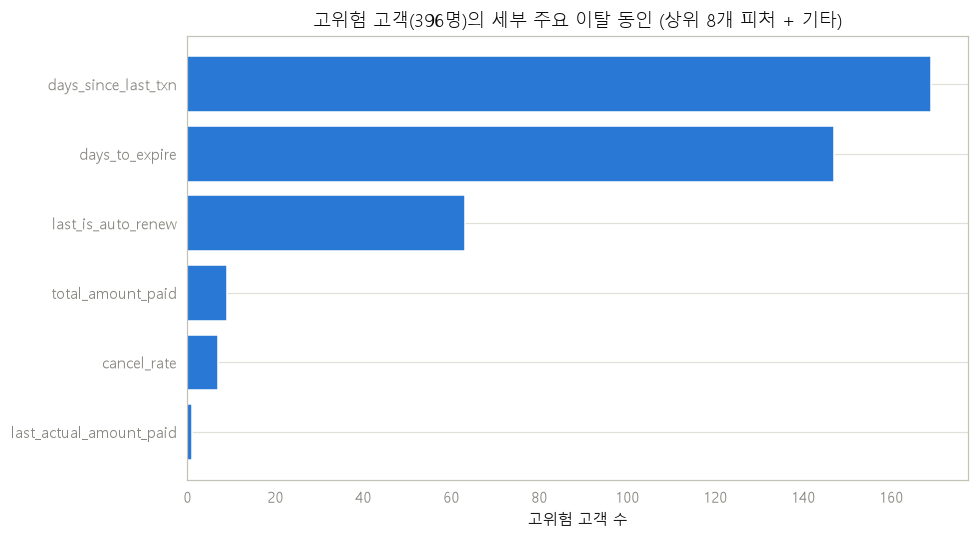

In [7]:
top_n = detail_summary.head(8)
other_count = detail_summary.iloc[8:].sum()
plot_data = pd.concat([top_n, pd.Series({"기타": other_count})]) if other_count > 0 else top_n

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data.index[::-1], plot_data.values[::-1], color=PALETTE[0])
ax.set_xlabel("고위험 고객 수")
ax.set_title(f"고위험 고객({len(high_risk):,}명)의 세부 주요 이탈 동인 (상위 8개 피처 + 기타)")
ax.grid(axis="x")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [8]:
# 세부 피처 -> 제안 액션 매핑 (실제로 수행/검증한 액션이 아니라 방향성 제안임을 명시)
action_map = {
    "days_since_last_txn": "장기 미결제 고객 리마인드 발송",
    "days_to_expire": "만료 임박 고객 대상 갱신 안내/프로모션",
    "last_is_auto_renew": "자동갱신 미설정 고객에게 자동갱신 전환 유도",
    "auto_renew_rate": "자동갱신 이력이 낮은 고객에게 자동갱신 혜택 안내",
    "cancel_rate": "과거 취소 이력이 있는 고객 대상 이탈 사유 설문/맞춤 오퍼",
    "last_plan_list_price": "요금제 부담 완화(다운그레이드/할인) 옵션 안내",
    "last_actual_amount_paid": "요금제 부담 완화(다운그레이드/할인) 옵션 안내",
    "total_amount_paid": "장기/고액 결제 고객 대상 VIP 리텐션 케어",
    "d7_active_days": "최근 7일 청취 급감 고객에게 개인화 추천 알림",
    "d30_active_days": "최근 30일 청취 감소 고객에게 개인화 추천 알림",
    "d90_active_days": "중기 청취 감소 고객에게 콘텐츠 추천 리마인드",
    "full_active_days": "저활동 고객 대상 온보딩/사용법 안내 강화",
    "trend_secs_recent15_vs_prior15": "청취량 급감 추세 고객에게 즉시 개인화 추천 발송",
    "tenure_days": "신규 가입자 대상 온보딩 강화",
}

segment_table = detail_summary.rename("고위험 고객 수").to_frame()
segment_table["비율(%)"] = (segment_table["고위험 고객 수"] / len(high_risk) * 100).round(1)
segment_table["제안 액션 (미검증, 방향성 제안)"] = segment_table.index.map(lambda f: action_map.get(f, "개별 분석 필요"))
segment_table.head(10)

,고위험 고객 수,비율(%),"제안 액션 (미검증, 방향성 제안)"
주요 이탈 동인(세부),,,
days_since_last_txn,169,42.7,장기 미결제 고객 리마인드 발송
days_to_expire,147,37.1,만료 임박 고객 대상 갱신 안내/프로모션
last_is_auto_renew,63,15.9,자동갱신 미설정 고객에게 자동갱신 전환 유도
total_amount_paid,9,2.3,장기/고액 결제 고객 대상 VIP 리텐션 케어
cancel_rate,7,1.8,과거 취소 이력이 있는 고객 대상 이탈 사유 설문/맞춤 오퍼
last_actual_amount_paid,1,0.3,요금제 부담 완화(다운그레이드/할인) 옵션 안내


In [9]:
# ------------------------------------------------------------------
# 해석 시 주의할 점
# 1. 05단계 SHAP 샘플(test split 5,000명) 내에서의 세그멘테이션이라 전체 모집단 비율과 다를 수 있다.
# 2. "주요 이탈 동인" = SHAP 기여도 합이 가장 큰 카테고리일 뿐, 실제 인과적 원인이 아니다.
# 3. "제안 액션"은 세그먼트 이름에서 상식적으로 도출한 방향성 제안이며, 실제 A/B 테스트 등으로
#    효과를 검증한 적은 없다 (검증은 로드맵의 다음 단계인 A/B 테스트 "설계" 문서에서 다룸).
# ------------------------------------------------------------------
print("고객 세그멘테이션 완료 (위 주석의 해석 주의사항 참고)")

고객 세그멘테이션 완료 (위 주석의 해석 주의사항 참고)
